# Tutorial

In [1]:
# Set-Up
import dotools_py as do

%matplotlib inline

Interactive plotting enabled (TkAgg).


In [6]:
paths = ['/tmp/dootools_datasets/healthy/outs/filtered_feature_bc_matrix.h5',
         '/tmp/dootools_datasets/disease/outs/filtered_feature_bc_matrix.h5']

adata = do.pp.importer_py(paths=paths,
                          ids=['batch1', 'batch2'],
                          metadata={'condition':['healthy', 'disease']},
                          batch_key='batch',
                          remove_doublets=True,
                          doublet_tool='Scrublet',
                          min_genes_in_cell=300,
                          min_cells_with_genes=5,
                          cut_mt=20,
                          n_reads=10_000,
                          min_counts=500,
                          high_quantile=95
                          )

2025-06-07 00:54:30,444 - Reading batch1


reading /tmp/dootools_datasets/healthy/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


2025-06-07 00:54:31,189 - Remove Cells with low number of genes


filtered out 14 cells that have less than 300 genes expressed


2025-06-07 00:54:31,260 - Remove Genes lowly expressed


...

extracting highly variable genes


... storing 'condition' as categorical
... storing 'doublet_class' as categorical


    finished (0:00:01)


2025-06-07 00:55:07,038 - Run PCA


computing PCA
    with n_comps=50
    finished (0:00:01)


In [12]:
adata

AnnData object with n_obs × n_vars = 14713 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_score', 'doublet_class', 'leiden'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'leiden_colors', 'batch_colors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'connectivities', 'distances'

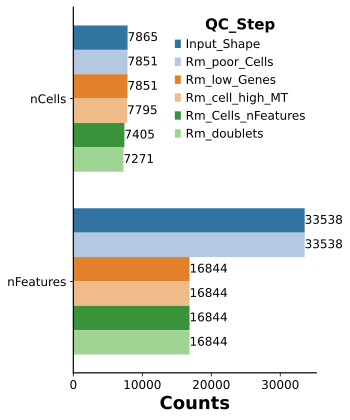

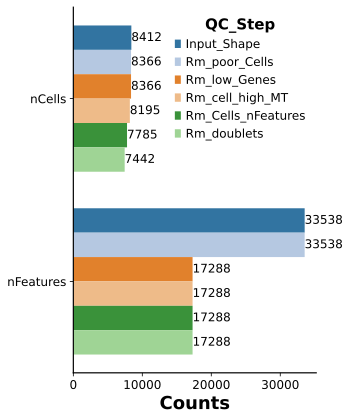

In [12]:
from IPython.display import SVG, display
display(SVG(filename='/tmp/dootools_datasets/healthy/outs/250607_QC_Metricsbatch1.svg'),
        SVG(filename='/tmp/dootools_datasets/disease/outs/250607_QC_Metricsbatch2.svg'),
        )

In [11]:
do.tl.integrate_data(adata,
                     batch_key='batch',
                     hvg_batch=True,
                     harmony=True)

2025-06-07 00:55:20,313 - Computing HVGs


extracting highly variable genes
    finished (0:00:01)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:01)


2025-06-07 00:55:24,064 - Integration using Harmony
2025-06-07 00:55:24,182 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
Computing initial centroids with sklearn.KMeans...
2025-06-07 00:55:27,943 - harmonypy - INFO - sklearn.KMeans initialization complete.
sklearn.KMeans initialization complete.
2025-06-07 00:55:28,024 - harmonypy - INFO - Iteration 1 of 100
Iteration 1 of 100
2025-06-07 00:55:29,860 - harmonypy - INFO - Iteration 2 of 100
Iteration 2 of 100
2025-06-07 00:55:31,474 - harmonypy - INFO - Converged after 2 iterations
Converged after 2 iterations
2025-06-07 00:55:31,481 - Finding neighbors


computing batch balanced neighbors
	finished (0:00:01)


2025-06-07 00:55:32,751 - Run UMAP


computing UMAP
    finished (0:00:03)


2025-06-07 00:55:35,809 - Clustering cells using Leiden (resolution 0.3)


running Leiden clustering
    finished (0:00:00)


In [14]:
adata.write('/tmp/dootools_datasets/adata.h5ad')

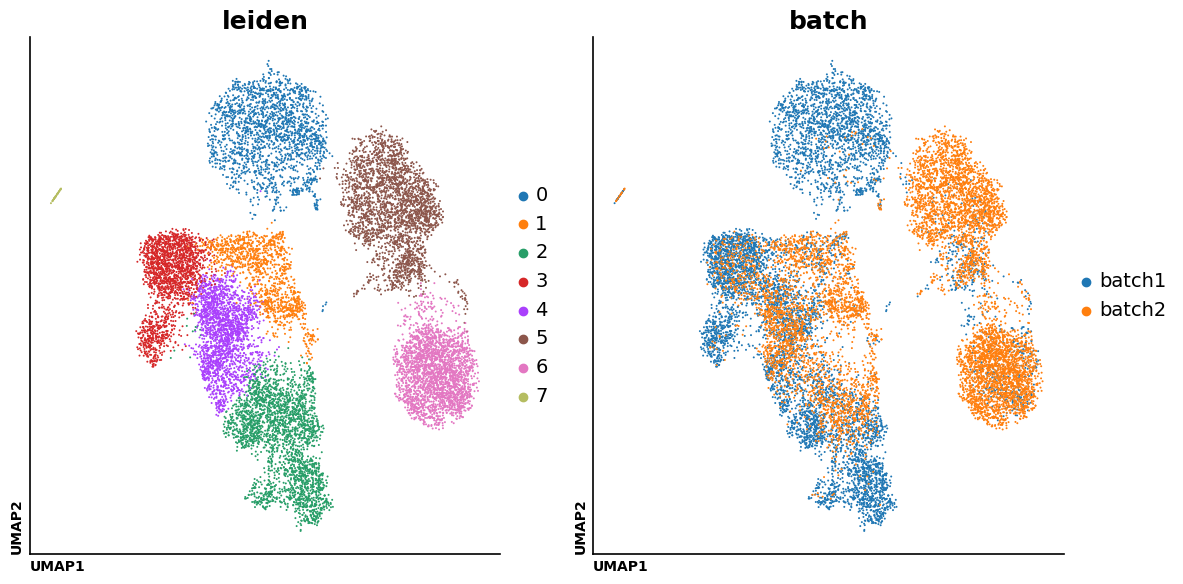

In [2]:
import scanpy as sc
adata = sc.read_h5ad('/tmp/dootools_datasets/adata.h5ad')
do.pl.umap(adata, ['leiden', 'batch'], show=True)

In [15]:
adata = do.tl.auto_annot(adata, 'leiden', model='Adult_COVID19_PBMC.pkl', convert=False, pl_cell_prob=True)

👉 Detailed model information can be found at `https://www.celltypist.org/models`
🔬 Input data has 14713 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 2895 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


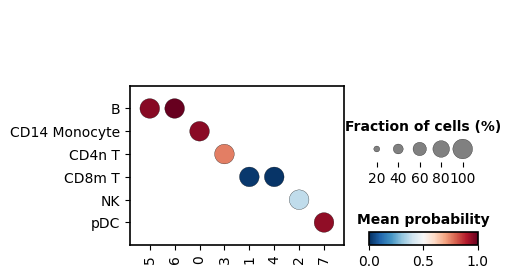

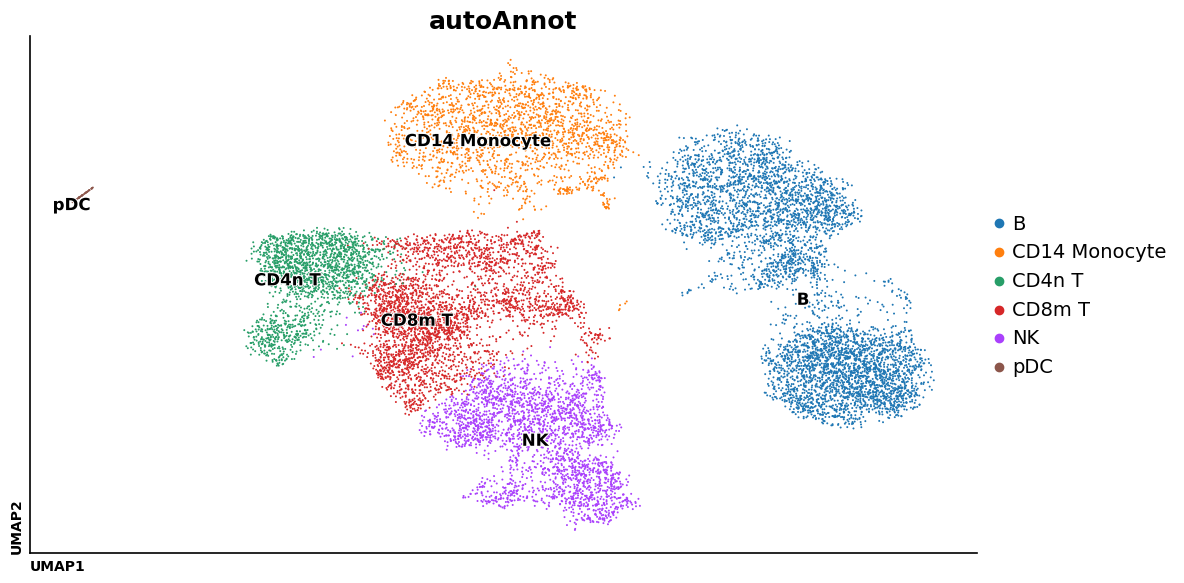

In [16]:
do.pl.umap(adata, 'autoAnnot', labels='autoAnnot')

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[WARNING] Consider setting transform='arcsin', as this produces more accurate results for simulated data.
[INFO] Simulation may take some minutes...
[INFO] Generating 5 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 1.72 seconds


2025-06-07 01:05:50,877 - There are 4 populations with a significant change


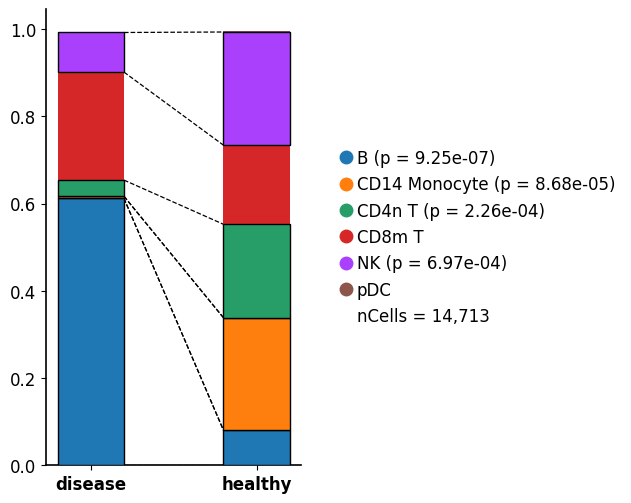

In [17]:
do.pl.cell_props(adata, 'autoAnnot', 'condition', 'batch')

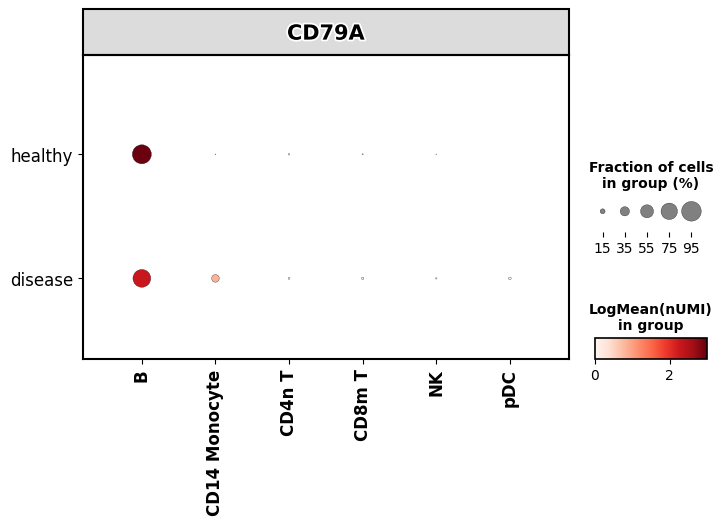

In [18]:

do.pl.dotplot(adata, 'autoAnnot', 'CD79A', y_axis='condition')

ranking genes


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished (0:00:07)


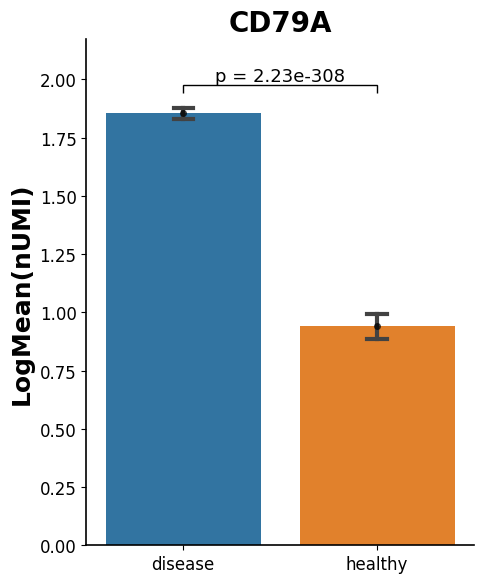

In [3]:
do.pl.barplot(adata, 'CD79A', 'condition', ctrl_cond='healthy', groups_cond='disease' )